<a href="https://colab.research.google.com/github/nhanmai001-ct1/TH_DeepLearning/blob/main/2001230598_MaiNguyenHoangNhan_TH_Buoi_03_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)
(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


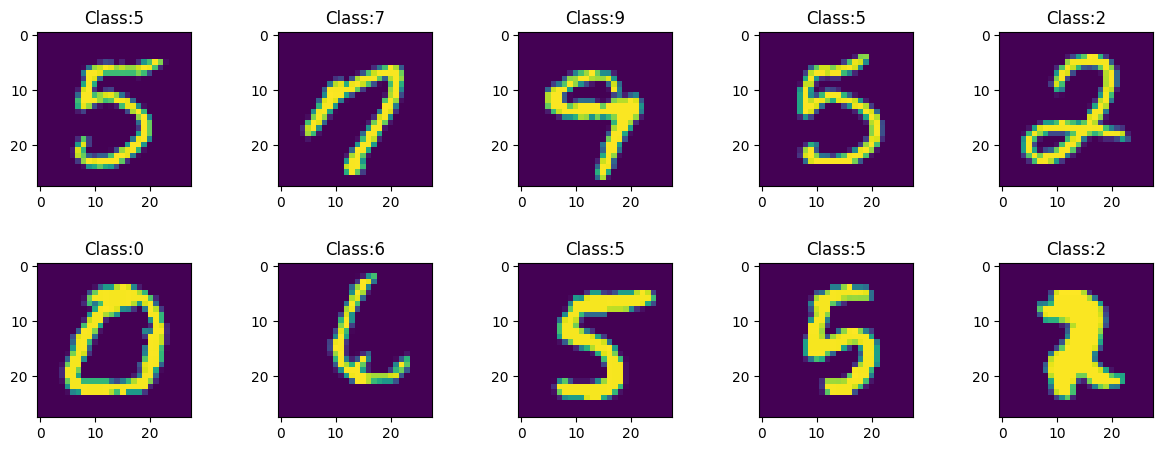

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input

import matplotlib.pyplot as plt

mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print (df_train.shape)
X_train = df_train.iloc [:,1:]
y_train = df_train.iloc [:,0]
X_test = df_test.iloc [:,1:]
y_test = df_test.iloc [:,0]
print (X_train.shape, y_train.shape, X_test.shape, y_test.shape)

num_classes = 10
input_shape = (28,28,1)
X_train = X_train.astype ("float32")/255
X_test = X_test.astype ("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape (X_train.shape[0], 28, 28, 1)
print (X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape (X_test.shape[0], 28, 28, 1)
print (X_test.shape)

print ('Number of classes: ', len(np.unique(y_train)))
print ('Classes: ', np.unique(y_train))
print (y_train [:5])
#Trực quan hóa 10 ảnh đầu
fig, axes = plt.subplots (nrows = 2, ncols = 5, figsize =(15,5))
ax = axes.ravel()
for i in range (10):
    ax [i].imshow(X_train[i].reshape(28,28))
    ax [i].title.set_text ('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

#Chuyển giá trị nhãn thành one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
model = Sequential()
model.add (Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

In [ ]:
#Huấn luyện mô hình
model.compile(optimizer='adam',loss ='categorical_crossentropy',metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.8390 - loss: 0.5945 - val_accuracy: 0.9415 - val_loss: 0.2093
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.9560 - loss: 0.1509 - val_accuracy: 0.9560 - val_loss: 0.1466
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.9696 - loss: 0.1033 - val_accuracy: 0.9660 - val_loss: 0.1171
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - accuracy: 0.9764 - loss: 0.0776 - val_accuracy: 0.9710 - val_loss: 0.0912
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.9798 - loss: 0.0640 - val_accuracy: 0.9740 - val_loss: 0.0944
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.9833 - loss: 0.0526 - val_accuracy: 0.9730 - val_loss: 0.0875
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.9852 - loss: 0.0462 - val_accuracy: 0.9745 - val_loss: 0.0830
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.9873 - loss: 0.0396 - 

### Đánh giá mô hình CNN

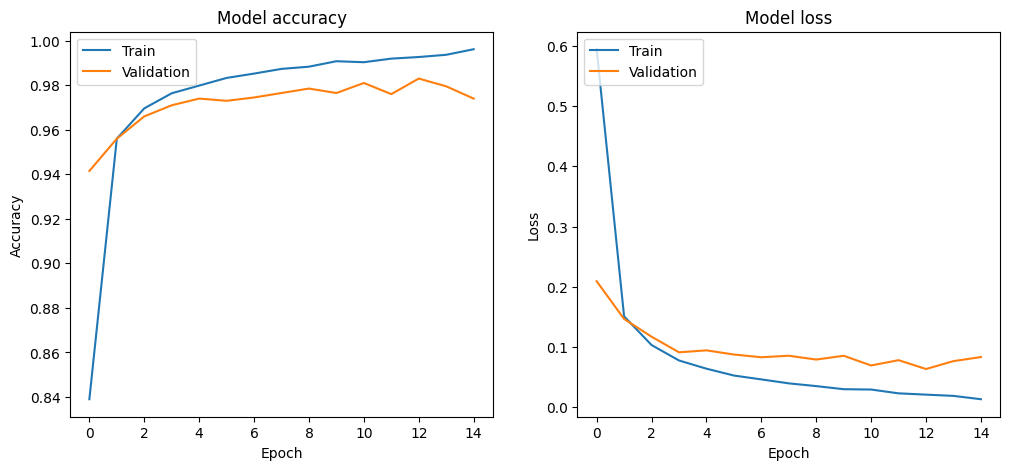

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

##Đánh giá mô hình CNN trên tập test

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])


313/313 - 3s - 8ms/step - accuracy: 0.9774 - loss: 0.0746
Test loss: 0.07464595884084702
Test accuracy: 0.9773977398872375


Dự báo nhãn cho ảnh sử dụng CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[[3.1986303e-06 1.5768937e-03 9.9841940e-01 7.9992066e-09 1.6061530e-19
  2.2104162e-13 3.4600831e-07 3.4848526e-15 8.7350209e-08 9.0668408e-18]]
2 2


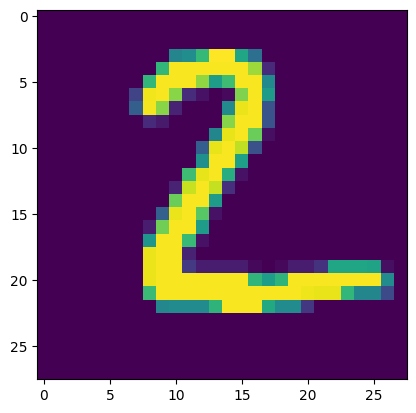

In [ ]:
predict = model.predict (X_test [:1])
print (predict)
print (np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[0].reshape(28,28))
plt.show()

#lưu mô hình
model.save_weights ('cnn.weights.h5')

##Nạp lại mô hình và tham số

Model and weights loaded successfully!


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
[[1.2679455e-06 9.9988842e-01 3.3370208e-05 7.7533241e-07 2.0072053e-05
  6.2111276e-08 3.4482839e-06 2.2309630e-05 3.0121204e-05 2.2116737e-08]]
1 1


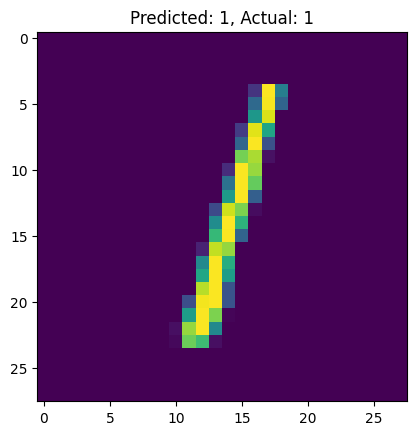

In [ ]:
# Nạp lại mô hình và các tham số

# Recreate the model architecture
reloaded_model = Sequential()
reloaded_model.add (Input(shape=input_shape))
reloaded_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
reloaded_model.add(MaxPool2D(pool_size=(2,2)))
reloaded_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
reloaded_model.add(MaxPool2D(pool_size=(2,2)))
reloaded_model.add(Flatten())
reloaded_model.add(Dense(units=10, activation='softmax'))

# Load the saved weights
reloaded_model.load_weights('cnn.weights.h5')

print("Model and weights loaded successfully!")
reloaded_model.summary()

# Make a prediction with the reloaded model for the second test image (index 1)
reloaded_predict = reloaded_model.predict(X_test[1:2])
print (reloaded_predict)
print(np.argmax(reloaded_predict), np.argmax(y_test[1]))
plt.imshow(X_test[1].reshape(28,28))
plt.title(f"Predicted: {np.argmax(reloaded_predict)}, Actual: {np.argmax(y_test[1])}")
plt.show()